In [162]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay

import math

In [163]:
# 1. Load the data from the CSV file into a pandas DataFrame
csv_file_path = '/Users/tvo/Documents/portfolio/college-notes/CSC 180/insurance_data.csv'

df = pd.read_csv(csv_file_path)
print("Original Data:")
print(df.head())
print("-" * 30)

Original Data:
   age  bought_insurance
0   22                 0
1   25                 0
2   47                 1
3   52                 0
4   46                 1
------------------------------


In [164]:
# Check for Missing Data
missing_cols = df.isna().any()
if missing_cols.any():
    cols_with_missing = missing_cols[missing_cols].index
    for col in cols_with_missing:
        print(f"Data Missing in {col}")
else:
    print("No Missing Data in Any Column")

No Missing Data in Any Column


In [165]:
# Split Training and Test Data
target = 'bought_insurance'
remove_cols = ['']
features = [col for col in df.columns if col != target and col not in remove_cols]

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=5) # 5 - 100%

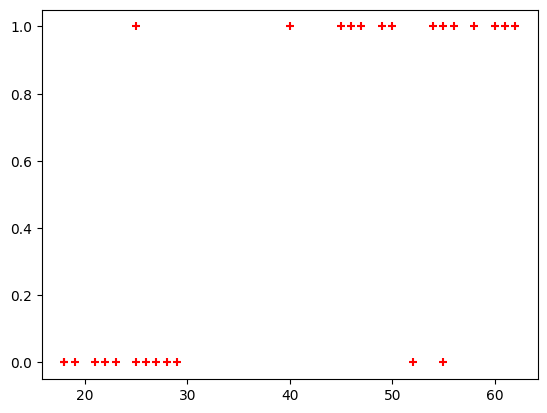

In [166]:
# Plot Data
plt.scatter(df.age, df.bought_insurance, marker='+', color='red')

In [167]:
# LinearRegrsssion
numeric_features = ['age']
categorical_features = []

transformer_steps = [
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
]

preprocessor = ColumnTransformer(transformers=transformer_steps)

pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression()) 
])

pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [168]:
print(f"Test set score: {pipe.score(X_test, y_test):.4f}")

model = pipe.named_steps['model']
feature_names = pipe.named_steps['preprocessor'].get_feature_names_out()

print("\nCoefficients:")
for name, coef in zip(feature_names, model.coef_):
    print(f"{name}: {coef:.2f}")

Test set score: 0.7647

Coefficients:
num__age: 0.29


In [169]:
# LogisticRegression
numeric_features = ['age']
categorical_features = []

transformer_steps = [
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
]

preprocessor = ColumnTransformer(transformers=transformer_steps)

pipe_lg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression()) 
])

pipe_lg.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Test set score: 1.0000


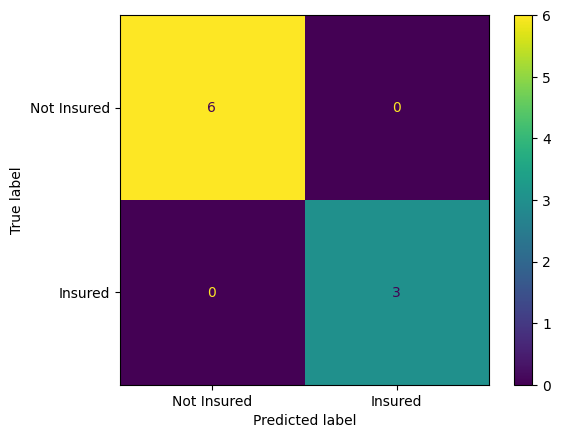

In [170]:
print(f"Test set score: {pipe_lg.score(X_test, y_test):.4f}")

y_pred = pipe_lg.predict(X_test)

class_names = ["Not Insured", "Insured"]
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=class_names) 

In [171]:
# RandomForestClassifier
numeric_features = ['age']
categorical_features = []

transformer_steps = [
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
]

preprocessor = ColumnTransformer(transformers=transformer_steps)

pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier()) 
])

pipe_rf.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Test set score: 1.0000


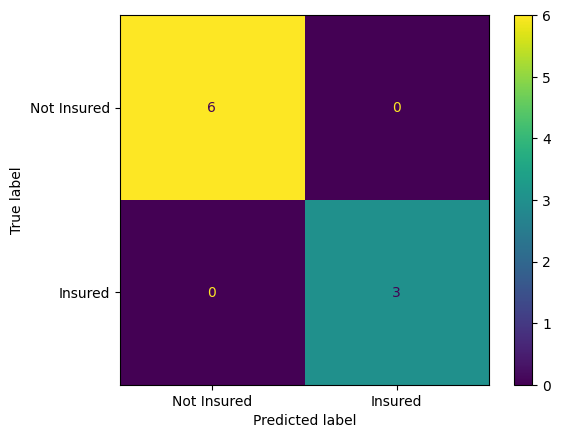

In [172]:
print(f"Test set score: {pipe_rf.score(X_test, y_test):.4f}")
y_pred = pipe_rf.predict(X_test)

class_names = ["Not Insured", "Insured"]
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=class_names) 

In [183]:
data_to_predict = pd.DataFrame([
    {'age': 1},
    {'age': 41},
    {'age': 30},
    {'age': 45},
    {'age': 100},
])

predictions_lg = pipe.predict(data_to_predict)
predictions_rf = pipe_rf.predict(data_to_predict)

for age, lg, rf in zip(data_to_predict['age'], predictions_lg, predictions_rf):
    print(f"A person {age} years old is..:")
    print(f"  - lg: Predicted Insured {lg * 100:,.2f}%")
    print(f"  - rf: Predicted Insured {rf * 100:,.2f}%")
    

A person 1 years old is..:
  - lg: Predicted Insured -28.26%
  - rf: Predicted Insured 0.00%
A person 41 years old is..:
  - lg: Predicted Insured 53.82%
  - rf: Predicted Insured 100.00%
A person 30 years old is..:
  - lg: Predicted Insured 31.24%
  - rf: Predicted Insured 0.00%
A person 45 years old is..:
  - lg: Predicted Insured 62.02%
  - rf: Predicted Insured 100.00%
A person 100 years old is..:
  - lg: Predicted Insured 174.88%
  - rf: Predicted Insured 100.00%


In [ ]:
import pickle

with open('pipe_rf - insurance.pkl', 'wb') as f:
    pickle.dump(pipe_rf, f)